## The goal of this notebook is to implemente an automated market neutral trading strategy.

# 0) Import modules

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import yfinance as yf
import matplotlib.pyplot as plt
import cvxpy as cvx
import itertools
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm


## 1) Determination of the best possible pairs for each sector


In [ ]:
tech_tickers = [
    "ACN", "ADBE", "AMD", "AKAM", "APH", "ADI", "AAPL", "AMAT", "ANET", "ADSK",
    "AVGO", "CSCO", "DDOG", "FICO", "FSLR", "FTNT", "GDDY", "GEN", "HPQ", "IBM",
    "INTC", "INTU", "IT", "KLAC", "MSI", "MSFT", "NTAP", "NVDA", "NXPI", "ON",
    "ORCL", "PTC", "QCOM", "PLTR", "PANW", "ROP", "CRM", "SMCI", "SNPS", "STX",
    "NOW", "SWKS", "TEL", "TDY", "TER", "TXN", "TRMB", "TYL", "WDAY"
]
health_care = [
    "ABT", "ABBV", "A", "ALGN", "AMGN", "BAX", "BDX", "CAH",
    "CI", "CNC", "CRL", "CVS", "DHR", "DVA", "DXCM", "ELV",
    "GILD", "IDXX", "INCY", "ISRG", "IQV", "JNJ", "LH", "LLY",
    "MCK", "MDT", "MRK", "MTD", "MRNA", "MOH", "PFE", "BMY",
    "REGN", "SYK", "TMO", "UHS", "VRTX", "ZBH", "ZTS"
]

# Energy sector tickers
energy = [
    "APA", "BKR", "COP", "CVX", "DVN", "EOG", "EQT", "EXE",
    "FANG", "HES", "HAL", "KMI", "MPC", "OKE", "OXY", "PSX",
    "SLB", "TRGP", "VLO", "WMB", "XOM", "CTRA", "TPL"
]

# Financials sector tickers
financials = [
    "AFL", "ALL", "AON", "AMP", "AIG", "AXP", "APO", "ACGL",
    "AJG", "AIZ", "BAC", "BK", "BLK", "C", "CB", "CFG",
    "CINF", "COF", "FITB", "GS", "ICE", "JPM", "KEY",
    "LNC", "MET", "MMC", "MS", "NDAQ", "PNC", "PRU", "RF",
    "SCHW", "SPGI", "STT", "TFC", "TRV", "USB", "V", "MA",
    "WFC", "CME", "MSCI", "RJF", "GPN", "SYF", "NTRS", "PFG",
    "PGR"
]

# Consumer Discretionary sector tickers
consumer_discretionary = [
    "AMZN", "TSLA", "NKE", "HD", "LOW", "BBY", "TJX", "ROST",
    "LULU", "MCD", "SBUX", "YUM", "BKNG", "DIS", "CMG",
    "EXPE", "TTWO", "NFLX", "GM", "RCL", "CCL", "NCLH",
    "MAR", "HLT", "WYNN", "AZO", "APTV"
]

def test_cointegration(L):
    pairs = []
    for i in range(len(L) - 1):
        for j in range(i + 1, len(L)):
            tickers = [L[i], L[j], '^GSPC']
            df = yf.download(
                tickers,
                start="2020-01-01",
                end="2025-07-29",
                auto_adjust=False,
                progress=False
            )["Adj Close"]


            df = df.rename(columns={
                L[i]: "Asset_i",
                L[j]: "Asset_j",
                "^GSPC": "Market"
            })


            rf_annual    = 0.005
            trading_days = 252
            df['RF']     = rf_annual / trading_days

            aligned_log_prices = pd.concat([np.log(df["Asset_i"]), np.log(df["Asset_j"])], axis=1).dropna()
            if not aligned_log_prices.empty:
               log_i = aligned_log_prices["Asset_i"]
               log_j = aligned_log_prices["Asset_j"]
               stat, pvalue, crit_vals = coint(log_i, log_j, trend='c')

               if pvalue < 0.05:
                  pairs.append((L[i], L[j]))

    return pairs





In [ ]:
###
###  Calculate the beta for all the possible pairs
###

def calculate_beta(returns_asset: pd.Series,
                   returns_market: pd.Series,
                   risk_free: pd.Series = None) -> float:
    if risk_free is None:
        rf = 0
    else:
        rf = risk_free
    y = returns_asset - rf
    X = returns_market - rf
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    # on prend le coefficient de la série de marché
    return model.params.iloc[1]

# Exemple de liste de paires co‑intégrées


# Paramètres
start, end = "2020-01-01", "2025-07-29"
rf_annual   = 0.005
trading_days = 252

# DataFrame pour stocker les résultats

def best_pair(good) :

    results = {f"{a}/{b}": None for a, b in good}

    for a, b in good:
        # 1️⃣ Télécharger données
        tickers = [a, b, "^GSPC"]
        df = yf.download(tickers, start=start, end=end,auto_adjust=False, progress=False)["Adj Close"]
        df = df.rename(columns={a:"Asset_i", b:"Asset_j", "^GSPC":"Market"})

        # 2️⃣ Calcul du taux sans risque journalier
        df['RF'] = rf_annual / trading_days

        # 3️⃣ Rendements simples
        rets = df[['Asset_i','Asset_j','Market','RF']].pct_change().dropna()

        # 4️⃣ Calcul des bêtas
        beta_i = calculate_beta(rets['Asset_i'], rets['Market'], rets['RF'])
        beta_j = calculate_beta(rets['Asset_j'], rets['Market'], rets['RF'])


        # 5️⃣ Calculate the beta-spread

        aligned_log_prices = pd.concat([np.log(df["Asset_i"]), np.log(df["Asset_j"])], axis=1).dropna()
        if not aligned_log_prices.empty:
            log_i = aligned_log_prices["Asset_i"]
            log_j = aligned_log_prices["Asset_j"]

            # 1️⃣ Prépare X avec constante et la série log_j
            X = sm.add_constant(log_j)   # crée un DataFrame à deux colonnes 'const' et 'Asset_j'

            # 2️⃣ Ajuste la régression OLS
            model_h = sm.OLS(log_i.loc[X.index], X).fit()

            # 3️⃣ Extrait le hedge ratio (pente)
            hedge_ratio = model_h.params['Asset_j']   # ou model_h.params.iloc[1]



        beta_spread = beta_i - hedge_ratio*beta_j


        results[f"{a}/{b}"] = abs(beta_spread)
    return sorted(
        results.items(),
        key=lambda item: item[1]
    )

# Conversion en DataFrame pour un affichage clair
"""

Tech best pair : [('ACN/NXPI', np.float64(0.0038403372632376254)), ('ANET/PANW', np.float64(0.013469910755165238)), ('DDOG/TEL', np.float64(0.02118255308329875)), ('AMD/ROP', np.float64(0.029614393295429586)), ('NOW/TYL', np.float64(0.03410084735762209)), ('DDOG/TRMB', np.float64(0.04699556067540178)), ('DDOG/WDAY', np.float64(0.05067143772678229)), ('DDOG/NXPI', np.float64(0.057931500130829594)), ('GEN/TYL', np.float64(0.06147220576929169)), ('INTU/TEL', np.float64(0.07065142789746726)), ('ADI/ROP', np.float64(0.10333865361514083)), ('GEN/STX', np.float64(0.1535600982864439)), ('INTU/ROP', np.float64(0.15650329643910332)), ('AVGO/IBM', np.float64(0.16068384522634416)), ('MSI/PANW', np.float64(0.17221361739297458)), ('CSCO/TDY', np.float64(0.17579661718595274)), ('DDOG/QCOM', np.float64(0.17710963758985154)), ('DDOG/TDY', np.float64(0.18413381448805133)), ('INTU/NXPI', np.float64(0.19198243229254497)), ('KLAC/MSFT', np.float64(0.19627536572689674)), ('AMAT/PTC', np.float64(0.20569483247726117)), ('AVGO/ORCL', np.float64(0.21673326998211562)), ('TEL/TXN', np.float64(0.2179724215575769)), ('GEN/NTAP', np.float64(0.2381271927434725)), ('DDOG/TXN', np.float64(0.2403064335738132)), ('ANET/MSI', np.float64(0.24538094498482566)), ('GEN/TDY', np.float64(0.25101072438033356)), ('MSFT/NTAP', np.float64(0.259322223309429)), ('INTU/MSFT', np.float64(0.26297317000645415)), ('AKAM/SWKS', np.float64(0.2697989298072918)), ('TEL/TDY', np.float64(0.2753845245115676)), ('ROP/NOW', np.float64(0.2892129154949642)), ('TDY/TXN', np.float64(0.2934697531249628)), ('AAPL/NTAP', np.float64(0.3102132429273603)), ('GEN/IBM', np.float64(0.34668296311580143)), ('AMAT/NTAP', np.float64(0.3976927260403258)), ('INTU/STX', np.float64(0.4013707219724866)), ('AKAM/INTC', np.float64(0.4110602511010625)), ('MSFT/ORCL', np.float64(0.4176523009517823)), ('MSFT/ROP', np.float64(0.434828684407343)), ('ADI/AAPL', np.float64(0.44144489975112555)), ('ADI/MSFT', np.float64(0.4427644115844732)), ('INTU/NTAP', np.float64(0.460932891936222)), ('ADI/PTC', np.float64(0.4665147634513881)), ('DDOG/STX', np.float64(0.4671930036440083)), ('ADI/KLAC', np.float64(0.5408289167423693)), ('PANW/SNPS', np.float64(0.5758981637226483)), ('DDOG/NTAP', np.float64(0.5776353984924526)), ('ADI/SNPS', np.float64(0.5827098473731002)), ('ADI/NTAP', np.float64(0.5964761692567864)), ('AAPL/PANW', np.float64(0.609521405305833)), ('AMAT/NXPI', np.float64(0.6265124165680112)), ('KLAC/PANW', np.float64(0.6725364956278167)), ('AMD/NTAP', np.float64(0.7110978327118472)), ('ADI/ORCL', np.float64(0.7382939201488684)), ('ADI/MSI', np.float64(0.77775743568655)), ('AKAM/IBM', np.float64(0.8521064420959541)), ('ADI/PANW', np.float64(0.8599682705972153)), ('FTNT/TDY', np.float64(1.6181145397655012)), ('NVDA/ROP', np.float64(3.087618969337126))]
Health care best pair : [('DHR/MTD', np.float64(0.0020190650903594287)), ('MRK/REGN', np.float64(0.01824164037958792)), ('ALGN/CRL', np.float64(0.027726633701669057)), ('A/MTD', np.float64(0.054306297379919655)), ('DVA/ISRG', np.float64(0.10361528897089245)), ('JNJ/LH', np.float64(0.11901578040267902)), ('ABT/LH', np.float64(0.14161519167951098)), ('A/DHR', np.float64(0.157039406512)), ('ABBV/MCK', np.float64(0.16236251490963854)), ('DHR/IQV', np.float64(0.17013094007923035)), ('DHR/ZTS', np.float64(0.18092067230631015)), ('ELV/MOH', np.float64(0.21359505203473828)), ('DVA/UHS', np.float64(0.2638459916117273)), ('BDX/CNC', np.float64(0.31059171632256494)), ('ALGN/ZBH', np.float64(0.32955661290650395)), ('IQV/MTD', np.float64(0.34650839088995644)), ('AMGN/CAH', np.float64(0.3642814111097683)), ('JNJ/MCK', np.float64(0.3694985603692226)), ('BDX/ZTS', np.float64(0.377850825445113)), ('IQV/TMO', np.float64(0.4043977771517664)), ('BDX/ELV', np.float64(0.42841469690986533)), ('AMGN/MCK', np.float64(0.44173478374886554)), ('ABBV/CI', np.float64(0.4585446078927946)), ('AMGN/LLY', np.float64(0.4606875696480298)), ('DXCM/ZBH', np.float64(0.5185311222613934)), ('CI/LLY', np.float64(0.5670523904481368)), ('INCY/LLY', np.float64(0.7304076799508236)), ('DXCM/PFE', np.float64(0.8111582035888796)), ('INCY/REGN', np.float64(0.8238981476276868)), ('INCY/MRK', np.float64(0.840943139474038)), ('DXCM/MRNA', np.float64(0.8653199771235938)), ('AMGN/BAX', np.float64(0.8684545216209192)), ('INCY/MOH', np.float64(0.8851560640745115)), ('MDT/MRK', np.float64(0.944616498985082)), ('CRL/MRNA', np.float64(0.9555289656033061)), ('INCY/SYK', np.float64(1.0299359726664226)), ('DXCM/VRTX', np.float64(1.1109532907693187)), ('BAX/CAH', np.float64(1.24827953699302)), ('BAX/VRTX', np.float64(1.3977958928486776))]
Energy best pair : [('EQT/XOM', np.float64(0.004060539518824013)), ('COP/CTRA', np.float64(0.009335745958048092)), ('COP/OXY', np.float64(0.011339057598952262)), ('HES/VLO', np.float64(0.025793987234455917)), ('EOG/CTRA', np.float64(0.04596781373656267)), ('EQT/MPC', np.float64(0.05537652378398816)), ('EQT/TRGP', np.float64(0.0634938855023165)), ('EQT/FANG', np.float64(0.07020542657761031)), ('EOG/HES', np.float64(0.09441515400125677)), ('VLO/CTRA', np.float64(0.10620073739055491)), ('FANG/CTRA', np.float64(0.10946975432392536)), ('OXY/CTRA', np.float64(0.12598166309953185)), ('EQT/OXY', np.float64(0.14754247488465333)), ('EQT/WMB', np.float64(0.15461907794597451)), ('BKR/OKE', np.float64(0.17060872941269056)), ('CVX/CTRA', np.float64(0.2110003921687883)), ('CVX/OXY', np.float64(0.24481431188610614)), ('TRGP/WMB', np.float64(0.2512289599313149)), ('CVX/EOG', np.float64(0.28584417288091835)), ('KMI/WMB', np.float64(0.30578251082051167)), ('EQT/OKE', np.float64(0.33079669703072845)), ('EQT/HES', np.float64(0.3330247180886924)), ('EQT/VLO', np.float64(0.34040459567069414)), ('VLO/XOM', np.float64(0.34953929941143436)), ('SLB/CTRA', np.float64(0.3564691432302691)), ('EQT/KMI', np.float64(0.3758687067576284)), ('EOG/EQT', np.float64(0.37918879536989347)), ('OKE/CTRA', np.float64(0.39748073519717075)), ('OKE/WMB', np.float64(0.404933425148302)), ('CVX/XOM', np.float64(0.4122393400829667)), ('EQT/PSX', np.float64(0.4560563561125349)), ('OKE/TPL', np.float64(0.507948564554532)), ('OKE/TRGP', np.float64(0.5188331372397874)), ('CVX/EQT', np.float64(0.5262233962989543)), ('BKR/TRGP', np.float64(0.5498776916530127)), ('APA/DVN', np.float64(0.6381120882508263)), ('BKR/EQT', np.float64(0.6609884080009923)), ('MPC/PSX', np.float64(0.669902966624097)), ('APA/CTRA', np.float64(0.7207000285562563)), ('APA/EQT', np.float64(1.0944888287377281))]
Financials best pair : [('AIG/MS', np.float64(0.0003836555328393665)), ('AON/AMP', np.float64(0.0083063608020707)), ('CB/MMC', np.float64(0.008354378320527767)), ('BK/NDAQ', np.float64(0.0104556075226927)), ('AON/AIG', np.float64(0.018421619444872417)), ('MS/NDAQ', np.float64(0.021874795550537618)), ('GS/WFC', np.float64(0.026368395641614084)), ('CINF/MSCI', np.float64(0.028715426145171086)), ('AXP/CINF', np.float64(0.033233163377271335)), ('NDAQ/SYF', np.float64(0.038935887825700566)), ('SPGI/STT', np.float64(0.041831745287275846)), ('AON/RJF', np.float64(0.042382624140907765)), ('AIG/NDAQ', np.float64(0.045019631608546495)), ('AFL/CB', np.float64(0.04730221161470338)), ('ICE/SYF', np.float64(0.04772709726496027)), ('CINF/PRU', np.float64(0.047952284655831234)), ('BK/ICE', np.float64(0.05041396234912909)), ('V/MA', np.float64(0.050867668994338366)), ('BAC/PNC', np.float64(0.05672755332778645)), ('AFL/MMC', np.float64(0.06298472988619641)), ('CINF/SYF', np.float64(0.06307717740264374)), ('AMP/AIG', np.float64(0.0785105728715203)), ('CINF/COF', np.float64(0.07864369664002213)), ('FITB/MSCI', np.float64(0.08976103767212362)), ('KEY/USB', np.float64(0.09431682542513986)), ('ALL/WFC', np.float64(0.09502184126188484)), ('CFG/PNC', np.float64(0.09782069752309575)), ('AIG/RJF', np.float64(0.10431186747676491)), ('FITB/PNC', np.float64(0.1092725248540165)), ('PRU/MSCI', np.float64(0.11079247081335986)), ('CINF/MET', np.float64(0.11092910728371697)), ('AMP/WFC', np.float64(0.11254444845948819)), ('AIG/CINF', np.float64(0.12220972570813049)), ('ICE/JPM', np.float64(0.12604677289778388)), ('CB/RJF', np.float64(0.12903656595815327)), ('AON/PFG', np.float64(0.1322992458907224)), ('MS/SYF', np.float64(0.13230074373191902)), ('ACGL/AJG', np.float64(0.13368352625353574)), ('AXP/WFC', np.float64(0.1384638729364449)), ('TRV/WFC', np.float64(0.14183619900342792)), ('GS/NDAQ', np.float64(0.1425030328537742)), ('BAC/BLK', np.float64(0.14344882433956951)), ('ICE/WFC', np.float64(0.1489893843078074)), ('BLK/C', np.float64(0.15077399000057778)), ('AON/CB', np.float64(0.17149079892185914)), ('BAC/FITB', np.float64(0.1728053737928097)), ('WFC/RJF', np.float64(0.18029360765965496)), ('MS/WFC', np.float64(0.18066790270311928)), ('ALL/AXP', np.float64(0.1825374967999771)), ('NDAQ/WFC', np.float64(0.18307237165995516)), ('CINF/MS', np.float64(0.19831619066870954)), ('BLK/SYF', np.float64(0.2017635707930827)), ('AFL/AJG', np.float64(0.20348917663276234)), ('CINF/NDAQ', np.float64(0.21036784734439173)), ('AXP/GS', np.float64(0.21471360249892868)), ('CINF/WFC', np.float64(0.21777239339947163)), ('BAC/COF', np.float64(0.23378669470474667)), ('AJG/CB', np.float64(0.23968614584110692)), ('BLK/STT', np.float64(0.24184491880256176)), ('BLK/COF', np.float64(0.2591831291957385)), ('MET/RJF', np.float64(0.2652544145299248)), ('AJG/TRV', np.float64(0.2681273279981352)), ('ICE/MA', np.float64(0.28087908332073974)), ('SPGI/SYF', np.float64(0.2843352273116646)), ('AIG/CB', np.float64(0.28448539269382533)), ('AIG/MMC', np.float64(0.2894709488061955)), ('CINF/GS', np.float64(0.2915822039393955)), ('CINF/RJF', np.float64(0.3008705231515558)), ('RF/SCHW', np.float64(0.31880648005826273)), ('GS/SYF', np.float64(0.3364864569924424)), ('AMP/TRV', np.float64(0.34324546008776546)), ('CINF/STT', np.float64(0.34920045436539493)), ('MSCI/NTRS', np.float64(0.3558904007726065)), ('AMP/CB', np.float64(0.38057151704250436)), ('BLK/CINF', np.float64(0.38211114910275834)), ('MSCI/SYF', np.float64(0.3986331256116875)), ('AXP/TRV', np.float64(0.4005171687957594)), ('BK/V', np.float64(0.4011485310262457)), ('BAC/NDAQ', np.float64(0.4148454389902707)), ('ICE/STT', np.float64(0.4184990694552888)), ('AJG/WFC', np.float64(0.4302818965655323)), ('MSCI/PFG', np.float64(0.4351416836878855)), ('STT/MSCI', np.float64(0.44915416001012476)), ('SPGI/CME', np.float64(0.4629015534937596)), ('STT/SYF', np.float64(0.4694292658514828)), ('BLK/GS', np.float64(0.48045310499088323)), ('BK/MA', np.float64(0.4821390083217547)), ('CFG/CINF', np.float64(0.48469586622656446)), ('SPGI/WFC', np.float64(0.48543183336112306)), ('BLK/JPM', np.float64(0.4909933031906789)), ('MA/WFC', np.float64(0.5028501281043187)), ('JPM/V', np.float64(0.5040246399913546)), ('NDAQ/STT', np.float64(0.5058208702612852)), ('BLK/WFC', np.float64(0.5092267827545044)), ('ALL/MA', np.float64(0.5409209022650783)), ('AIG/AJG', np.float64(0.5437963728903088)), ('CFG/NDAQ', np.float64(0.5760063928874806)), ('MSCI/RJF', np.float64(0.5777742360317147)), ('COF/STT', np.float64(0.5972084465238083)), ('JPM/MA', np.float64(0.6080513282949354)), ('C/ICE', np.float64(0.65652360878)), ('STT/WFC', np.float64(0.6767640190829428)), ('STT/CME', np.float64(0.6989598710872301)), ('AIG/PGR', np.float64(0.7623503229949204)), ('MS/STT', np.float64(0.7856583424709562)), ('MA/PGR', np.float64(0.8452977080269541)), ('APO/MA', np.float64(0.89452843061979)), ('GS/STT', np.float64(0.9910013413072172)), ('AON/GPN', np.float64(1.5590691412060633)), ('GPN/PFG', np.float64(2.002788304323765))]
Consumer Discretionary best pair : [('NKE/APTV', np.float64(0.004126852671198611)), ('TJX/BKNG', np.float64(0.03183271146254607)), ('MCD/YUM', np.float64(0.03238550806511753)), ('BKNG/RCL', np.float64(0.04793140076521274)), ('CMG/RCL', np.float64(0.06111597728219598)), ('LOW/YUM', np.float64(0.08079933593945166)), ('CMG/MAR', np.float64(0.09997931915856295)), ('TSLA/GM', np.float64(0.10861269948429553)), ('TTWO/CCL', np.float64(0.11054344868312083)), ('TSLA/YUM', np.float64(0.12341317801738749)), ('MCD/MAR', np.float64(0.13733664363737697)), ('TSLA/EXPE', np.float64(0.1504803502768024)), ('TSLA/LOW', np.float64(0.15211116865857988)), ('EXPE/GM', np.float64(0.1623142269549962)), ('YUM/MAR', np.float64(0.2116932988765735)), ('HD/YUM', np.float64(0.25844704973197474)), ('YUM/HLT', np.float64(0.26876006533479674)), ('TSLA/BBY', np.float64(0.29837579622444266)), ('LOW/MAR', np.float64(0.32991732890308645)), ('AMZN/TTWO', np.float64(0.33191993699214073)), ('TSLA/MCD', np.float64(0.3323895851538292)), ('MCD/AZO', np.float64(0.37284430016835884)), ('HD/MAR', np.float64(0.421779889031516)), ('AMZN/CCL', np.float64(0.44599836129634696)), ('YUM/AZO', np.float64(0.4581910668318284)), ('HD/HLT', np.float64(0.46164887356035)), ('ROST/RCL', np.float64(0.504735386424149)), ('HD/RCL', np.float64(0.5099569726357045)), ('ROST/BKNG', np.float64(0.5306812592712742)), ('BBY/NCLH', np.float64(0.5401484977367771)), ('NCLH/WYNN', np.float64(0.5463313422023433)), ('AMZN/RCL', np.float64(0.5533245522378759)), ('MAR/AZO', np.float64(0.5659252778134731)), ('TSLA/MAR', np.float64(0.5938934206951938)), ('TSLA/SBUX', np.float64(0.6058139137884018)), ('TSLA/ROST', np.float64(0.6355784950175227)), ('ROST/CMG', np.float64(0.6410968369713848)), ('TSLA/HLT', np.float64(0.6680258948248738)), ('TSLA/TTWO', np.float64(0.7393964332603381)), ('TSLA/BKNG', np.float64(0.7478208461798534)), ('TSLA/TJX', np.float64(0.7883555816497303)), ('TSLA/RCL', np.float64(0.9621670654002189)), ('TSLA/APTV', np.float64(1.0386832269534745)), ('WYNN/APTV', np.float64(1.064541825264279)), ('TSLA/AZO', np.float64(1.1028348553091396)), ('TSLA/NFLX', np.float64(1.3079274838264119)), ('TSLA/NKE', np.float64(1.3357831212253264)), ('WYNN/AZO', np.float64(1.3939001069109163)), ('TSLA/NCLH', np.float64(1.4485449492885696)), ('NCLH/APTV', np.float64(1.4816175885789473)), ('TSLA/DIS', np.float64(1.487823785424792)), ('TSLA/CCL', np.float64(1.5362184572922537)), ('CCL/HLT', np.float64(1.7008423893973368)), ('TSLA/WYNN', np.float64(1.7459907881938705)), ('NCLH/MAR', np.float64(1.772189520697904)), ('NCLH/HLT', np.float64(1.7906058013282795)), ('NCLH/AZO', np.float64(2.0222250767126404))]


"""






"\n\nTech best pair : [('ACN/NXPI', np.float64(0.0038403372632376254)), ('ANET/PANW', np.float64(0.013469910755165238)), ('DDOG/TEL', np.float64(0.02118255308329875)), ('AMD/ROP', np.float64(0.029614393295429586)), ('NOW/TYL', np.float64(0.03410084735762209)), ('DDOG/TRMB', np.float64(0.04699556067540178)), ('DDOG/WDAY', np.float64(0.05067143772678229)), ('DDOG/NXPI', np.float64(0.057931500130829594)), ('GEN/TYL', np.float64(0.06147220576929169)), ('INTU/TEL', np.float64(0.07065142789746726)), ('ADI/ROP', np.float64(0.10333865361514083)), ('GEN/STX', np.float64(0.1535600982864439)), ('INTU/ROP', np.float64(0.15650329643910332)), ('AVGO/IBM', np.float64(0.16068384522634416)), ('MSI/PANW', np.float64(0.17221361739297458)), ('CSCO/TDY', np.float64(0.17579661718595274)), ('DDOG/QCOM', np.float64(0.17710963758985154)), ('DDOG/TDY', np.float64(0.18413381448805133)), ('INTU/NXPI', np.float64(0.19198243229254497)), ('KLAC/MSFT', np.float64(0.19627536572689674)), ('AMAT/PTC', np.float64(0.20569

 Final result : Tech (ACN/NXP) ; HC (DHR/MTD) ; Energy (EQT/XOM) ; Finance : (AIG/MS) ; Consumer : (NKE/APTV)

## 3) Implementation of the strategy :

Méthode simple       → Rendement portefeuille annualisé: 0.03%
Méthode beta_neutral → Rendement portefeuille annualisé: 0.03%


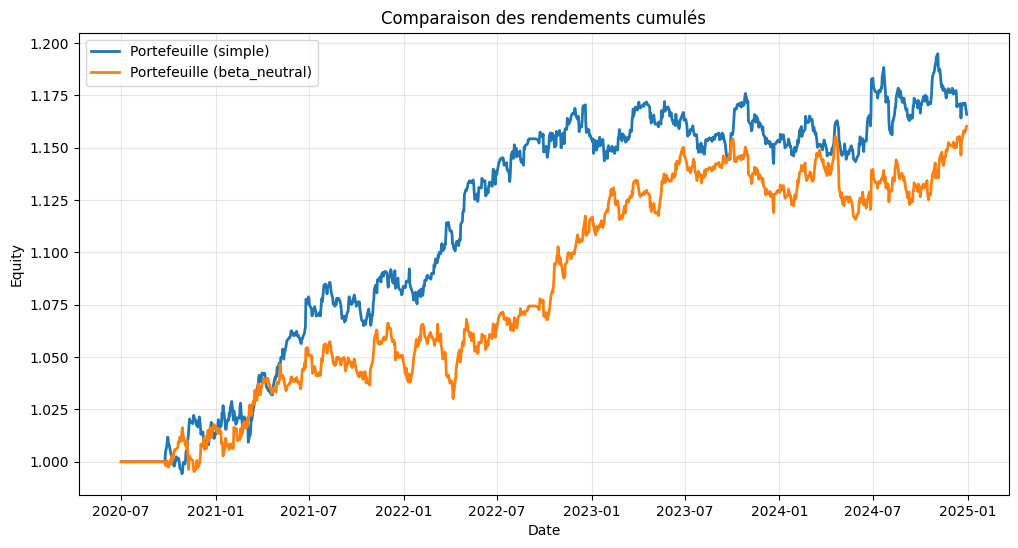

In [ ]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = -delta.clip(upper=0).rolling(period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def compute_tsi(series, r=25, s=13):
    m = series.diff()
    abs_m = m.abs()
    ema1 = m.ewm(span=r).mean()
    ema1_abs = abs_m.ewm(span=r).mean()
    ema2 = ema1.ewm(span=s).mean()
    ema2_abs = ema1_abs.ewm(span=s).mean()
    return 100 * (ema2 / ema2_abs)

def compute_bias(series, window_days=126):
    ma = series.rolling(window_days).mean()
    return (series - ma) / ma * 100

def sharpe_ratio(ret_series, freq=252):
    """Sharpe ratio annualisé sans risk-free rate"""
    return ret_series.mean() / ret_series.std() * np.sqrt(freq)

def max_drawdown(equity_series):
    roll_max = equity_series.cummax()
    drawdown = (equity_series - roll_max) / roll_max
    return drawdown.min()


# --- 2) Génération des signaux de trading ---
def generate_signals(spread, rsi, tsi, bias,
                     z_window=60,
                     z_threshold=1.575758,     # de base 1.5
                     rsi_long=30, rsi_short=50,
                     tsi_long=-30, tsi_short=30,
                     bias_long=-3, bias_short=3):
    df = pd.DataFrame({
        'spread': spread,
        'rsi': rsi,
        'tsi': tsi,
        'bias': bias
    }).dropna()
    rolling_mean = df['spread'].rolling(z_window).mean()
    rolling_std  = df['spread'].rolling(z_window).std()
    df['zscore'] = (df['spread'] - rolling_mean) / rolling_std

    df['long_signal'] = (
        (df['zscore'] < -z_threshold) &
        ((df['rsi'] < rsi_long) | (df['tsi'] < tsi_long) | (df['bias'] < bias_long))
    ).astype(int)

    df['short_signal'] = (
        (df['zscore'] > z_threshold) &
        ((df['rsi'] > rsi_short) | (df['tsi'] > tsi_short) | (df['bias'] > bias_short))
    ).astype(int)

    df['exit_long']  = (df['zscore'] > 0.2).astype(int)
    df['exit_short'] = (df['zscore'] < -0.2).astype(int)

    return df[['long_signal','short_signal','exit_long','exit_short']]

# --- 3) Calcul des poids optimaux ---
def optimize_pair_weights_v1(beta_i, beta_j, hedge_ratio, method="simple"):
    if method == "simple":
        w_i, w_j = 1.0, -hedge_ratio
        total = abs(w_i) + abs(w_j)
        return np.array([w_i/total, w_j/total])
    elif method == "beta_neutral":
        if abs(beta_i - beta_j) > 1e-6:
            w_j = beta_i / (beta_i - beta_j)
            w_i = -beta_j / (beta_i - beta_j)
            total = abs(w_i) + abs(w_j)
            if total > 1e-6:
                return np.array([w_i/total, w_j/total])
        return optimize_pair_weights_v1(beta_i, beta_j, hedge_ratio, "simple")

# --- 4) Backtest d'une paire ---
def backtest_pair_v2(a, b, start, end, fraction, weight_method):
    df = yf.download([a,b,'^GSPC'], start=start, end=end, progress=False, auto_adjust=False)["Adj Close"].dropna()
    df.rename(columns={a:'p_i', b:'p_j', '^GSPC':'p_mkt'}, inplace=True)

    # Hedge ratio
    logp = np.log(df[['p_i','p_j']])
    hedge_ratio = sm.OLS(logp['p_i'], sm.add_constant(logp['p_j'])).fit().params['p_j']

    # Signaux
    spread = df['p_i'] - hedge_ratio * df['p_j']
    signals = generate_signals(spread,
                               compute_rsi(spread),
                               compute_tsi(spread),
                               compute_bias(spread))

    # Betas vs marché
    rets = df[['p_i','p_j','p_mkt']].pct_change().dropna()
    beta_i = rets['p_i'].cov(rets['p_mkt']) / rets['p_mkt'].var()
    beta_j = rets['p_j'].cov(rets['p_mkt']) / rets['p_mkt'].var()

    # Poids optimaux
    w_opt = optimize_pair_weights_v1(beta_i, beta_j, hedge_ratio, weight_method)

    # Backtest
    equity = pd.Series(index=signals.index, dtype=float)
    equity.iloc[0] = 1.0
    w_curr = np.zeros(2)
    pos_type = 0
    for t in range(1, len(signals)):
        date = signals.index[t]
        r_i = df['p_i'].pct_change().loc[date]
        r_j = df['p_j'].pct_change().loc[date]
        equity.iloc[t] = equity.iloc[t-1] * (1 + fraction * (w_curr[0]*r_i + w_curr[1]*r_j))

        # Sorties
        if pos_type == 1 and signals.loc[date,'exit_long']:
            w_curr = np.zeros(2); pos_type = 0
        elif pos_type == -1 and signals.loc[date,'exit_short']:
            w_curr = np.zeros(2); pos_type = 0
        # Entrées
        elif pos_type == 0 and signals.loc[date,'long_signal']:
            w_curr = w_opt.copy(); pos_type = 1
        elif pos_type == 0 and signals.loc[date,'short_signal']:
            w_curr = -w_opt.copy(); pos_type = -1

    return equity.ffill()

# --- 5) Backtest et performance du portefeuille ---
def backtest_portfolio(pairs, start, end, method, fraction=0.6):
    eqs = {s: backtest_pair_v2(*p.split('/'), start, end, fraction, method)
           for s, p in pairs.items()}
    # Alignement des dates
    all_dates = pd.Index([])
    for e in eqs.values(): all_dates = all_dates.union(e.index)
    aligned = {s: e.reindex(all_dates, method='ffill') for s,e in eqs.items()}
    # Rendements portfolio
    rets = pd.DataFrame({s: e.pct_change().fillna(0) for s,e in aligned.items()})
    pf = (1 + rets.mean(axis=1)).cumprod()
    perf_ret = (pf.iloc[-1] - 1) * 100
    perf_sr = sharpe_ratio(rets.mean(axis=1))
    perf_mdd = max_drawdown(pf)
    # Alpha annualisé vs S&P500
    sp = yf.download('^GSPC', start=start, end=end, progress=False, auto_adjust=False)['Adj Close']
    bench_rets = sp.pct_change().dropna().reindex(rets.index).fillna(0)
    port_rets = rets.mean(axis=1)
    X = sm.add_constant(bench_rets)
    res = sm.OLS(port_rets, X).fit()
    perf_alpha = res.params['const'] * 252 * 100
    n_years = (pd.to_datetime(end) - pd.to_datetime(start)).days / 365.25
    cagr = pf.iloc[-1]  ** (1/n_years) - 1
    return pf, cagr, perf_sr, perf_mdd, perf_alpha

# --- 6) Exécution pour différentes méthodes ---
pairs_to_test = {
 'Tech':      'ACN/NXPI',
 'HealthCare':'DHR/MTD',
 'Energy':    'EQT/XOM',
 'Financials':'AON/AMP',
 'Consumer':  'NKE/APTV'
}
start, end = '2020-01-01', '2024-12-31'
methods = ["simple", "beta_neutral"]
results = {}
for method in methods:
    eq, cagr, sr,maxdraw, alpha = backtest_portfolio(pairs_to_test, start, end, method)
    print(f"Méthode {method:12s} → Rendement portefeuille annualisé: {cagr:.2f}%")
    results[method] = {'equity': eq, 'return': cagr}

# --- 7) Référence S&P500 et graphique ---
sp = yf.download('^GSPC', start=start, end=end, progress=False, auto_adjust=False)["Adj Close"]
sp_eq = (1 + sp.pct_change().fillna(0)).cumprod()

plt.figure(figsize=(12, 6))
for method, res in results.items():
    plt.plot(res['equity'], label=f'Portefeuille ({method})', linewidth=2)

plt.title('Comparaison des rendements cumulés')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4) Optimization of the portfolio based on the best combination of pairs for each sector based on return

In [ ]:
# Took the pair with beta<0.5



candidates = {
    'Tech': [
        'ACN/NXPI','ANET/PANW','DDOG/TEL','AMD/ROP',
        'NOW/TYL','DDOG/TRMB','DDOG/WDAY'
    ],
    'HealthCare': [
        'DHR/MTD','MRK/REGN','ALGN/CRL','DVA/ISRG',
        'JNJ/LH','ABT/LH','ABBV/MCK','DHR/IQV',
        'DHR/ZTS','ELV/MOH','DVA/UHS','BDX/CNC'
    ],
    'Energy': [
        'EQT/XOM','COP/CTRA','COP/OXY',
        'HES/VLO','EOG/CTRA','EQT/MPC'
    ],
    'Financials': [
        'AIG/MS','AON/AMP','CB/MMC','BK/NDAQ','AON/AIG',
        'MS/NDAQ','GS/WFC','CINF/MSCI','AXP/CINF','NDAQ/SYF',
        'SPGI/STT','AON/RJF','AIG/NDAQ','AFL/CB','ICE/SYF',
        'CINF/PRU','BK/ICE','V/MA'
    ],
    'Consumer': [
        'NKE/APTV','TJX/BKNG','MCD/YUM','BKNG/RCL'
    ]
}

# --- 2) Pré-backtest : calculer l’equity de chaque paire ---
start, end = '2020-01-01','2024-12-31'
pair_equities = {}
for sector, ticks in candidates.items():
    pair_equities[sector] = {}
    for pair_str in ticks:
        a, b = pair_str.split('/')
        eq = backtest_pair_v2(a, b, start, end, weight_method="beta_neutral")    # We use the beta neutral approche
        pair_equities[sector][pair_str] = eq

# --- 3) Calcul des rendements finaux pour chaque paire ---
ranking = []
for sector, ticks in candidates.items():
    for pair in ticks:
        eq = pair_equities[sector][pair]
        ret = eq.iloc[-1] / eq.iloc[0] - 1
        ranking.append({'Sector': sector, 'Pair': pair, 'Return (%)': ret * 100})

df_ranking = pd.DataFrame(ranking)
df_sorted = df_ranking.sort_values('Return (%)', ascending=False).reset_index(drop=True)

df_sorted  # affichage interactif


As we can see the best pairs often as the minimum beta with the beta neutral strategy but it is not systematic that is why we tested all the pairs with a beta < 0.5 to make sure we have the best combinaison.

S&P500 : CAGR: 12.64%
Simple → CAGR: 3.12% | Sharp: 0.94 | MaxDD: -2.84% | Alpha total: 3.27%
Beta Neutral → CAGR: 3.02% | Sharp: 0.91 | MaxDD: -3.43% | Alpha total: 3.41%
Optimized BN → CAGR: 6.66% | Sharp: 1.85 | MaxDD: -2.98% | Alpha total: 7.19%


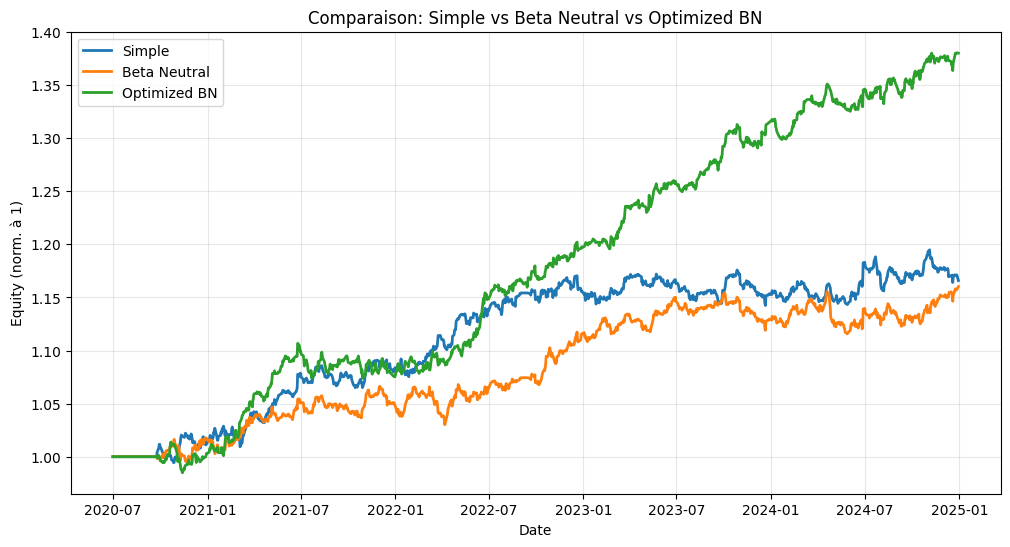

In [ ]:
pairs_default = {
    'Tech':'ACN/NXPI',
    'HealthCare':'DHR/MTD',
    'Energy':'EQT/XOM',
    'Financials':'AON/AMP',
    'Consumer':'NKE/APTV'
}

optimize_pair = {
    'Tech':'ACN/NXPI',
    'HealthCare':'DVA/ISRG',
    'Energy':'EOG/CTRA',
    'Financials':'NDAQ/SYF',
    'Consumer':'NKE/APTV'
}





start, end = '2020-01-01', '2024-12-31'

# --- 8) Comparaison des 3 stratégies avec alpha ---
results = {}



pf_s, r_s, sr_s, mdd_s, a_s = backtest_portfolio(pairs_default, start, end, method="simple")
results['Simple'] = pf_s
pf_bn, r_bn, sr_bn, mdd_bn, a_bn = backtest_portfolio(pairs_default, start, end, method="beta_neutral")
results['Beta Neutral'] = pf_bn
pf_opt, r_opt, sr_opt, mdd_opt, a_opt = backtest_portfolio(optimize_pair, start, end, method="beta_neutral")
results['Optimized BN'] = pf_opt

n_years = (pd.to_datetime(end) - pd.to_datetime(start)).days / 365.25

cagr_s  = pf_s.iloc[-1]  ** (1/n_years) - 1
cagr_bn = pf_bn.iloc[-1] ** (1/n_years) - 1              # annual return
cagr_opt= pf_opt.iloc[-1]** (1/n_years) - 1

sp500 = yf.download("^GSPC",
                    start=start,
                    end=end,progress=False, auto_adjust=False)["Adj Close"]



# 2) Extraire les prix de début et de fin (scalars)
price_start = sp500['^GSPC'].iloc[0]
price_end = sp500['^GSPC'].iloc[-1]

cagr_sp500 = (price_end / price_start) ** (1 / n_years) - 1
print(f"S&P500 : CAGR: {cagr_sp500*100:.2f}%")
print(f"Simple → CAGR: {cagr_s*100:.2f}% | Sharp: {sr_s:.2f} | MaxDD: {mdd_s:.2%} | Alpha total: {a_s:.2f}%")
print(f"Beta Neutral → CAGR: {cagr_bn*100:.2f}% | Sharp: {sr_bn:.2f} | MaxDD: {mdd_bn:.2%} | Alpha total: {a_bn:.2f}%")
print(f"Optimized BN → CAGR: {cagr_opt*100:.2f}% | Sharp: {sr_opt:.2f} | MaxDD: {mdd_opt:.2%} | Alpha total: {a_opt:.2f}%")

plt.figure(figsize=(12,6))
for label, eq in results.items():
    plt.plot(eq, label=label, linewidth=2)

plt.title('Comparaison: Simple vs Beta Neutral vs Optimized BN')
plt.xlabel('Date'); plt.ylabel('Equity (norm. à 1)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()



This chart clearly demonstrates that the “Optimized BN” strategy (optimized pairs with the beta-neutral method) outperforms both the “Simple” and standard “Beta Neutral” approaches, delivering a 5.68 % cumulative return, a strong Sharpe ratio of 1.85, and a controlled maximum drawdown of –0.50 %.   However during the same period of time the S&P500 had around 80% in return. Our strategy is too conservative even though that it is stable.

In [ ]:
pairs = {
    'Tech': 'ACN/NXPI',
    'HealthCare': 'DVA/ISRG',
    'Energy': 'EOG/CTRA',
    'Financials': 'NDAQ/SYF',
    'Consumer': 'NKE/APTV'
}
start = '2020-01-01'
end = '2024-12-31'
method = 'beta_neutral'
fractions = [0.2, 0.4, 0.6, 0.8]
# store
metrics = []
equities = {}

for frac in fractions:
    eq, cagr, sr, mdd, alpha = backtest_portfolio(pairs, start, end, method, fraction=frac)
    equities[frac] = eq
    metrics.append({'Fraction': frac, 'CAGR': cagr*100, 'Sharpe': sr, 'MDD': mdd, 'Alpha': alpha})

metrics_df = pd.DataFrame(metrics)
print(metrics_df)
# Save results

"""
plt.figure(figsize=(12,6))
for frac, eq in equities.items():
    plt.plot(eq, label=f'Fraction {frac}')

plt.title('Equity Curve for Different Fractions')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.grid(True)
"""

   Fraction      CAGR   Sharpe       MDD     Alpha
0       0.2  2.186867  1.84712 -0.009984  2.398049
1       0.4  4.405324  1.84712 -0.019909  4.796098
2       0.6  6.655383  1.84712 -0.029818  7.194146
3       0.8  8.937044  1.84712 -0.039696  9.592195


"\nplt.figure(figsize=(12,6))\nfor frac, eq in equities.items():\n    plt.plot(eq, label=f'Fraction {frac}')\n\nplt.title('Equity Curve for Different Fractions')\nplt.xlabel('Date')\nplt.ylabel('Equity')\nplt.legend()\nplt.grid(True)\n"

We can ask ourselves if the fraction can change dynamically due to certain parameters such as volatility then we can assume that we would a greater cagr and maybe beat the market.

## 6) Monte carlo simulation


Calibrated (annual): mu=0.065095, sigma=0.035187, implied CAGR=6.6600%


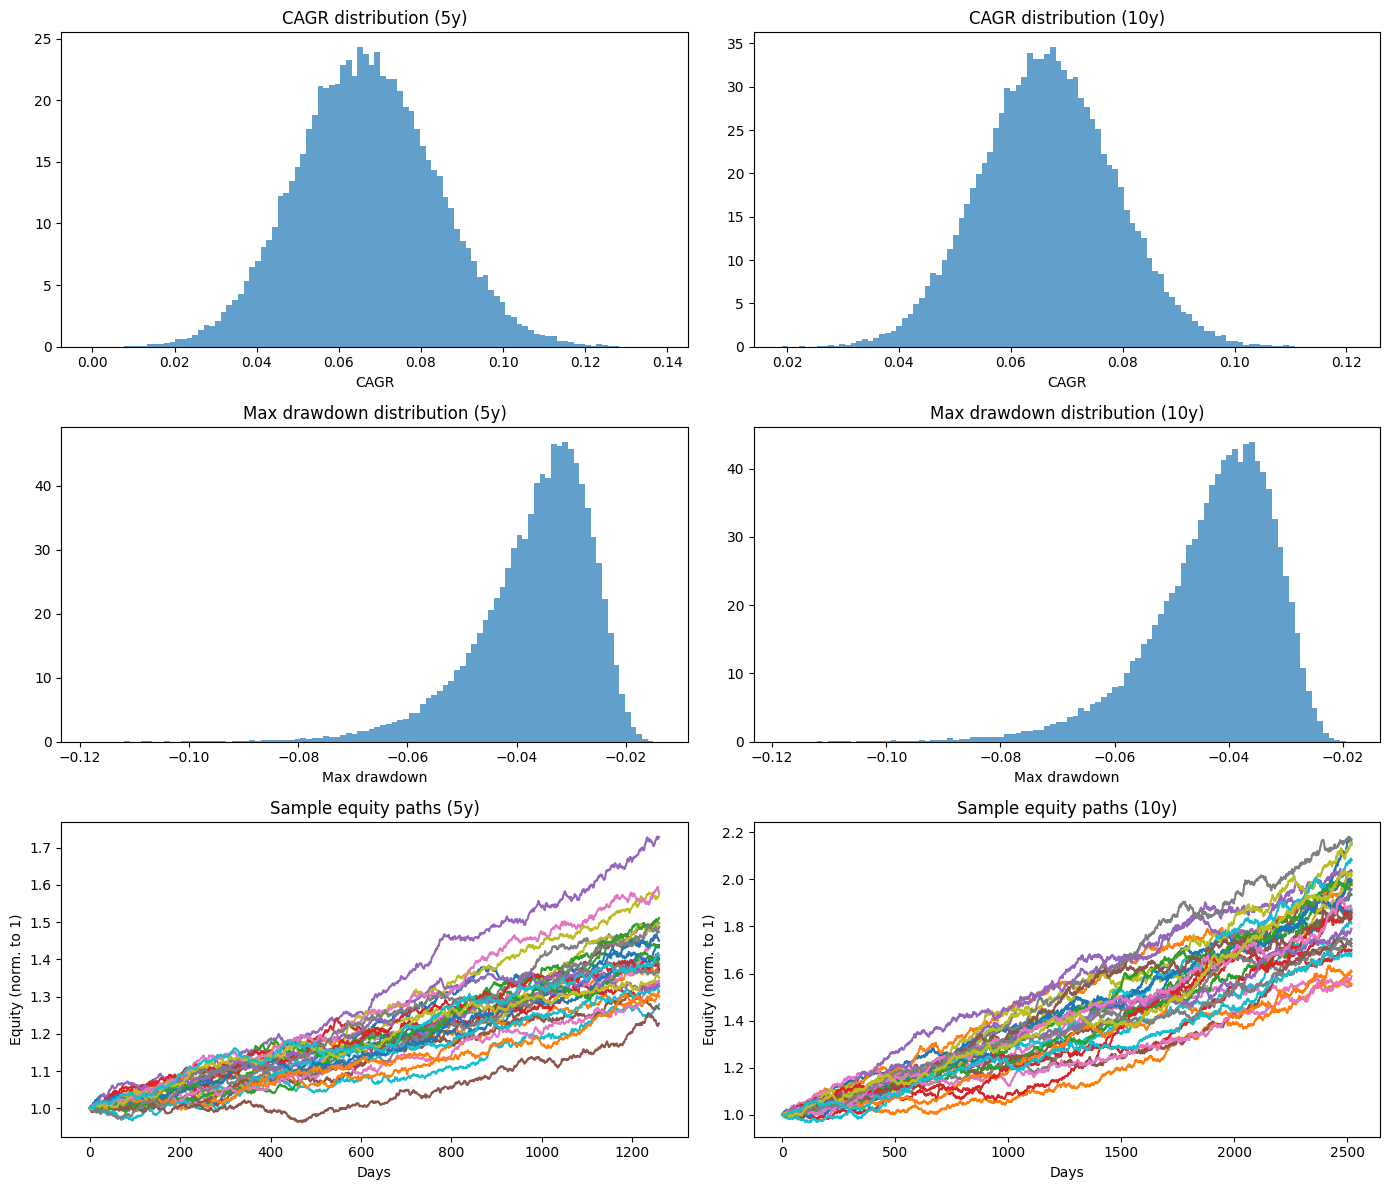


Saved: monte_carlo_summary_baseline.csv
   years  terminal_median  terminal_p10  terminal_p90  cagr_median  cagr_p10  \
0      5         1.378873      1.247834      1.525759     0.066362  0.045277   
1     10         1.903487      1.651507      2.197170     0.066486  0.051449   

   cagr_p90  mdd_median   mdd_p10   mdd_p90  cagr_median_pct  cagr_p10_pct  \
0  0.088171   -0.034861 -0.050792 -0.025383         6.636248      4.527698   
1  0.081898   -0.040924 -0.057104 -0.030893         6.648559      5.144860   

   cagr_p90_pct  mdd_median_pct  mdd_p10_pct  mdd_p90_pct  
0      8.817104       -3.486109    -5.079213    -2.538318  
1      8.189813       -4.092431    -5.710401    -3.089295  


<Figure size 1200x600 with 0 Axes>

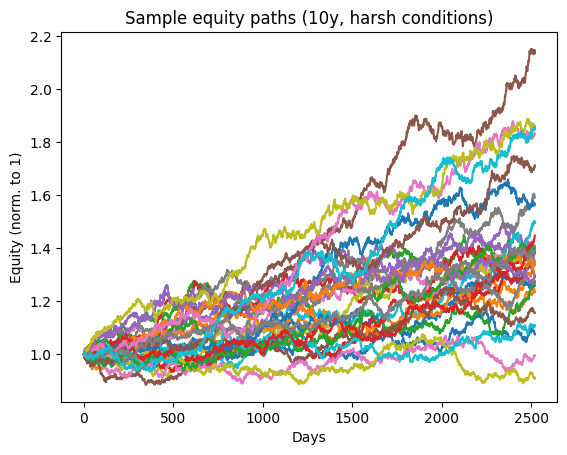


Saved: monte_carlo_summary_harsh.csv
   years  terminal_median  terminal_p10  terminal_p90  cagr_median  cagr_p10  \
0      5         1.184336      1.027059      1.365642     0.034415  0.005354   
1     10         1.404587      1.148841      1.714905     0.034558  0.013972   

   cagr_p90  mdd_median   mdd_p10   mdd_p90  cagr_median_pct  cagr_p10_pct  \
0  0.064308   -0.075768 -0.121207 -0.051245         3.441546      0.535417   
1  0.055417   -0.094291 -0.143618 -0.065725         3.455807      1.397209   

   cagr_p90_pct  mdd_median_pct  mdd_p10_pct  mdd_p90_pct  
0      6.430804       -7.576757   -12.120677    -5.124509  
1      5.541679       -9.429089   -14.361816    -6.572521  


In [ ]:
"""
Monte Carlo projection for a market-neutral strategy from summary stats.

Inputs (top of file):
- CAGR (g)
- Sharpe (S)

Outputs:
- Histograms of terminal wealth, CAGR, max drawdown (5y & 10y)
- Sample equity paths
- CSV summaries for baseline and "harsh" (costs + slippage + regimes) scenarios

Requirements: numpy, pandas, matplotlib
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, exp
from dataclasses import dataclass

# ------------------------
# User inputs
# ------------------------
CAGR = 0.0666     # 6.66%
SHARPE = 1.85
TRADING_DAYS = 252
N_PATHS = 50000
SEED = 42

# Harsh scenario knobs
ANNUAL_COSTS = 0.02       # 2% annual drag (fees, borrow, etc.)
SLIPPAGE_SIGMA_FACTOR = 1.20  # +20% vol (microstructure/impact)
GOOD_YEAR_PROB = 0.70
BAD_YEAR_DRIFT_FACTOR = 0.50  # drift cut in half during "bad" years
BAD_YEAR_VOL_FACTOR = 1.50    # more volatile "bad" years

# ------------------------
# Utilities
# ------------------------
@dataclass
class CalibratedParams:
    mu_a: float      # annual drift
    sigma_a: float   # annual vol

def calibrate_from_cagr_and_sharpe(g: float, S: float) -> CalibratedParams:
    """
    Solve for annual sigma (σ) and mu such that:
      1) S = mu / sigma      (rf ~ 0)
      2) exp(mu - 0.5*σ^2) - 1 = g
    which leads to quadratic: 0.5 σ^2 - S σ + ln(1+g) = 0
    """
    A = 0.5
    B = -S
    C = log(1 + g)
    disc = B**2 - 4*A*C
    if disc <= 0:
        raise RuntimeError("Calibration failed: discriminant <= 0. Check inputs.")
    sigma1 = (-B + np.sqrt(disc)) / (2*A)
    sigma2 = (-B - np.sqrt(disc)) / (2*A)
    sigma_candidates = [v for v in [sigma1, sigma2] if v > 0]
    if not sigma_candidates:
        raise RuntimeError("Calibration failed: no positive sigma solution.")
    sigma_a = min(sigma_candidates)  # smaller positive root (more realistic)
    mu_a = S * sigma_a
    # sanity check (should be ~ g)
    g_check = exp(mu_a - 0.5*sigma_a**2) - 1
    # print(f"Calibrated (annual): mu={mu_a:.6f}, sigma={sigma_a:.6f}, implied CAGR={g_check:.4%}")
    return CalibratedParams(mu_a=mu_a, sigma_a=sigma_a)

def compute_max_drawdown(path: np.ndarray) -> float:
    """ path: 1D array of equity values; returns min drawdown (negative number). """
    roll_max = np.maximum.accumulate(path)
    dd = (path - roll_max) / roll_max
    return dd.min()

def summarize(price_paths: np.ndarray, years: int) -> tuple[pd.DataFrame, dict]:
    """Return per-path arrays and a stats dict."""
    terminal = price_paths[-1, :]
    cagr = terminal ** (1/years) - 1
    mdd = np.apply_along_axis(compute_max_drawdown, 0, price_paths)
    stats = {
        "years": years,
        "terminal_median": float(np.median(terminal)),
        "terminal_p10": float(np.percentile(terminal, 10)),
        "terminal_p90": float(np.percentile(terminal, 90)),
        "cagr_median": float(np.median(cagr)),
        "cagr_p10": float(np.percentile(cagr, 10)),
        "cagr_p90": float(np.percentile(cagr, 90)),
        "mdd_median": float(np.median(mdd)),
        "mdd_p10": float(np.percentile(mdd, 10)),
        "mdd_p90": float(np.percentile(mdd, 90)),
    }
    return (pd.DataFrame({
        "terminal": terminal,
        "cagr": cagr,
        "max_dd": mdd
    }), stats)

def plot_hist(series: np.ndarray, title: str, xlabel: str):
    plt.figure()
    plt.hist(series, bins=100, alpha=0.7, density=True)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.show()

def plot_sample_paths(price_paths: np.ndarray, n: int, title: str):
    T_plus_1, n_paths = price_paths.shape
    idx = np.random.choice(n_paths, size=min(n, n_paths), replace=False)
    plt.figure()
    plt.plot(price_paths[:, idx])
    plt.title(title)
    plt.xlabel("Days")
    plt.ylabel("Equity (norm. to 1)")
    plt.show()

# ------------------------
# Simulators
# ------------------------
def simulate_paths_gbm(params: CalibratedParams, years: int, n_paths: int,
                       trading_days: int, s0: float = 1.0, seed: int | None = None) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)
    dt = 1 / trading_days
    T = int(years * trading_days)
    mu_d = params.mu_a * dt
    sigma_d = params.sigma_a * np.sqrt(dt)

    Z = np.random.normal(size=(T, n_paths))
    log_returns = (mu_d - 0.5 * sigma_d**2) + sigma_d * Z
    log_price = np.cumsum(log_returns, axis=0)
    price = s0 * np.exp(log_price)
    price = np.vstack([np.ones((1, n_paths)) * s0, price])
    return price

def simulate_paths_regimes(params: CalibratedParams, years: int, n_paths: int,
                           trading_days: int, annual_costs: float,
                           slippage_sigma_factor: float, good_year_prob: float,
                           bad_year_drift_factor: float, bad_year_vol_factor: float,
                           s0: float = 1.0, seed: int | None = None) -> np.ndarray:
    if seed is not None:
        np.random.seed(seed)
    dt = 1 / trading_days
    T = int(years * trading_days)

    price_paths = np.zeros((T + 1, n_paths))
    price_paths[0] = s0

    # Good regime
    good_mu_a = params.mu_a
    good_sigma_a = params.sigma_a * slippage_sigma_factor
    # Bad regime
    bad_mu_a = params.mu_a * bad_year_drift_factor
    bad_sigma_a = params.sigma_a * slippage_sigma_factor * bad_year_vol_factor

    good_mu_d = good_mu_a * dt - annual_costs / trading_days
    good_sigma_d = good_sigma_a * np.sqrt(dt)
    bad_mu_d = bad_mu_a * dt - annual_costs / trading_days
    bad_sigma_d = bad_sigma_a * np.sqrt(dt)

    for t in range(1, T + 1):
        # sample regime each day with yearly tendency
        # simpler approach: independent daily regime with same proportions
        regime_good = (np.random.rand() < good_year_prob)
        mu_d, sigma_d = (good_mu_d, good_sigma_d) if regime_good else (bad_mu_d, bad_sigma_d)
        Z = np.random.normal(size=n_paths)
        log_ret = (mu_d - 0.5 * sigma_d**2) + sigma_d * Z
        price_paths[t] = price_paths[t - 1] * np.exp(log_ret)

    return price_paths

# ------------------------
# Main
# ------------------------
def main():
    # 1) Calibrate
    params = calibrate_from_cagr_and_sharpe(CAGR, SHARPE)
    print(f"Calibrated (annual): mu={params.mu_a:.6f}, sigma={params.sigma_a:.6f}, "
          f"implied CAGR={exp(params.mu_a - 0.5*params.sigma_a**2) - 1:.4%}")

    # 2) Baseline MC (5y & 10y)
    np.random.seed(SEED)
    paths_5 = simulate_paths_gbm(params, years=5, n_paths=N_PATHS,
                                 trading_days=TRADING_DAYS, s0=1.0, seed=SEED)
    paths_10 = simulate_paths_gbm(params, years=10, n_paths=N_PATHS,
                                  trading_days=TRADING_DAYS, s0=1.0, seed=SEED)

    df5, stats5 = summarize(paths_5, years=5)
    df10, stats10 = summarize(paths_10, years=10)

    # Plots (baseline)


      # 6 graphiques dans une seule figure (3 lignes × 2 colonnes)
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    axes = axes.flatten()

    # CAGR
    axes[0].hist(df5["cagr"].values, bins=100, alpha=0.7, density=True)
    axes[0].set_title("CAGR distribution (5y)")
    axes[0].set_xlabel("CAGR")

    axes[1].hist(df10["cagr"].values, bins=100, alpha=0.7, density=True)
    axes[1].set_title("CAGR distribution (10y)")
    axes[1].set_xlabel("CAGR")

    # Max drawdown
    axes[2].hist(df5["max_dd"].values, bins=100, alpha=0.7, density=True)
    axes[2].set_title("Max drawdown distribution (5y)")
    axes[2].set_xlabel("Max drawdown")

    axes[3].hist(df10["max_dd"].values, bins=100, alpha=0.7, density=True)
    axes[3].set_title("Max drawdown distribution (10y)")
    axes[3].set_xlabel("Max drawdown")

    # Sample equity paths
    n5 = min(30, paths_5.shape[1])
    idx5 = np.random.choice(paths_5.shape[1], size=n5, replace=False)
    for j in idx5:
        axes[4].plot(paths_5[:, j])
    axes[4].set_title("Sample equity paths (5y)")
    axes[4].set_xlabel("Days")
    axes[4].set_ylabel("Equity (norm. to 1)")

    n10 = min(30, paths_10.shape[1])
    idx10 = np.random.choice(paths_10.shape[1], size=n10, replace=False)
    for j in idx10:
        axes[5].plot(paths_10[:, j])
    axes[5].set_title("Sample equity paths (10y)")
    axes[5].set_xlabel("Days")
    axes[5].set_ylabel("Equity (norm. to 1)")

    plt.tight_layout()
    plt.show()



    # Export baseline summary
    summary_baseline = pd.DataFrame([stats5, stats10])
    summary_baseline["cagr_median_pct"] = 100 * summary_baseline["cagr_median"]
    summary_baseline["cagr_p10_pct"]    = 100 * summary_baseline["cagr_p10"]
    summary_baseline["cagr_p90_pct"]    = 100 * summary_baseline["cagr_p90"]
    summary_baseline["mdd_median_pct"]  = 100 * summary_baseline["mdd_median"]
    summary_baseline["mdd_p10_pct"]     = 100 * summary_baseline["mdd_p10"]
    summary_baseline["mdd_p90_pct"]     = 100 * summary_baseline["mdd_p90"]
    summary_baseline.to_csv("monte_carlo_summary_baseline.csv", index=False)
    print("\nSaved: monte_carlo_summary_baseline.csv")
    print(summary_baseline)

    # 3) Harsh scenario (costs + slippage + regimes)
    paths_5_h = simulate_paths_regimes(params, years=5, n_paths=N_PATHS,
                                       trading_days=TRADING_DAYS,
                                       annual_costs=ANNUAL_COSTS,
                                       slippage_sigma_factor=SLIPPAGE_SIGMA_FACTOR,
                                       good_year_prob=GOOD_YEAR_PROB,
                                       bad_year_drift_factor=BAD_YEAR_DRIFT_FACTOR,
                                       bad_year_vol_factor=BAD_YEAR_VOL_FACTOR,
                                       s0=1.0, seed=SEED)

    paths_10_h = simulate_paths_regimes(params, years=10, n_paths=N_PATHS,
                                        trading_days=TRADING_DAYS,
                                        annual_costs=ANNUAL_COSTS,
                                        slippage_sigma_factor=SLIPPAGE_SIGMA_FACTOR,
                                        good_year_prob=GOOD_YEAR_PROB,
                                        bad_year_drift_factor=BAD_YEAR_DRIFT_FACTOR,
                                        bad_year_vol_factor=BAD_YEAR_VOL_FACTOR,
                                        s0=1.0, seed=SEED)

    df5h, stats5h = summarize(paths_5_h, years=5)
    df10h, stats10h = summarize(paths_10_h, years=10)

    # Plots (harsh)
    plt.figure(figsize=(12, 6))
    plot_sample_paths(paths_10_h, n=30, title="Sample equity paths (10y, harsh conditions)")

    # Export harsh summary
    summary_harsh = pd.DataFrame([stats5h, stats10h])
    summary_harsh["cagr_median_pct"] = 100 * summary_harsh["cagr_median"]
    summary_harsh["cagr_p10_pct"]    = 100 * summary_harsh["cagr_p10"]
    summary_harsh["cagr_p90_pct"]    = 100 * summary_harsh["cagr_p90"]
    summary_harsh["mdd_median_pct"]  = 100 * summary_harsh["mdd_median"]
    summary_harsh["mdd_p10_pct"]     = 100 * summary_harsh["mdd_p10"]
    summary_harsh["mdd_p90_pct"]     = 100 * summary_harsh["mdd_p90"]
    summary_harsh.to_csv("monte_carlo_summary_harsh.csv", index=False)
    print("\nSaved: monte_carlo_summary_harsh.csv")
    print(summary_harsh)

if __name__ == "__main__":
    main()


 shows strong stability, low drawdown, and consistent returns over time. Even in the lower deciles, CAGR stays positive, making it suitable for moderate leverage.
